In [36]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet

from tqdm.auto import tqdm

from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import models
import inference
import utils

In [97]:
category = 0
size = 128
threshold = 0.5

In [98]:
def plot_mask(image, mask):
    mask = np.array(mask)
    masked = np.ma.masked_where(mask == 0, mask)
    plt.imshow(np.array(image))
    plt.imshow(masked, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()
    
def IoU(mask1, mask2):
    mask1 = np.array(mask1, dtype=float)
    mask2 = np.array(mask2, dtype=float)
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    
    return np.sum(intersection) / np.sum(union)

In [99]:
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types=("segmentation", "category"),
    download=True
)

test_dataset = OxfordIIITPet(
    root="data",
    split="test",
    target_types=("segmentation", "category"),
    download=True
)

In [100]:
def preprocess(mask):
    return mask.point(lambda p: 1 if p == 1 or p == 3 else 0)

def downscale(image, mask, size):
    small_image = image.copy()
    small_image.thumbnail((size,size))
    
    small_mask = mask.copy()
    small_mask.thumbnail((size,size))
    
    image = np.array(small_image)
    mask = np.array(small_mask)
    
    return image, mask

def upscale(image, shape):
    pil_img = Image.fromarray(image.astype(np.uint8))
    up_img = pil_img.resize((shape[0], shape[1]), resample=Image.BILINEAR)
    up_img = np.array(up_img)
    
    return up_img

In [101]:
idx_train = []
for i, (image, (mask, cat)) in tqdm(enumerate(dataset), total=len(dataset)):
    if cat == category:
        idx_train.append(i)

idx_test = []
for i, (image, (mask, cat)) in tqdm(enumerate(test_dataset), total=len(test_dataset)):
    if cat == category:
        idx_test.append(i)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

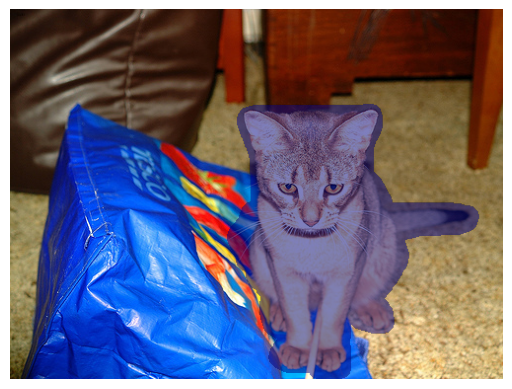

In [102]:
i = 5

image, (mask, cat) = dataset[idx_train[i]]
mask = preprocess(mask)

plot_mask(image, mask)

In [59]:
features = []
labels = []

for i in tqdm(idx_train):
    image, (mask, cat) = dataset[i]
    mask = preprocess(mask)
    image, mask = downscale(image, mask, size)
    mask = mask > threshold
    fg = image[mask]
    features.append(fg)
    labels.append(np.ones(len(fg)))
    bg = image[~mask]
    features.append(bg)
    labels.append(np.zeros(len(bg)))

features = np.concatenate(features)
labels = np.concatenate(labels)

idx_0 = np.where(labels == 0)[0]
idx_1 = np.where(labels == 1)[0]

n = min(len(idx_0), len(idx_1))

idx_0_balanced = np.random.choice(idx_0, size=n, replace=False)
idx_1_balanced = np.random.choice(idx_1, size=n, replace=False)

balanced_idx = np.concatenate([idx_0_balanced, idx_1_balanced])
np.random.shuffle(balanced_idx)

features = features[balanced_idx]
labels = labels[balanced_idx]


  0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.5, random_state=42, stratify=labels
)

logisticMask = models.LogisticMask(solver="newton-cholesky")
densityMask = models.DensityMask()

logisticMask.fit(X_train, y_train)
densityMask.fit(X_train, y_train)

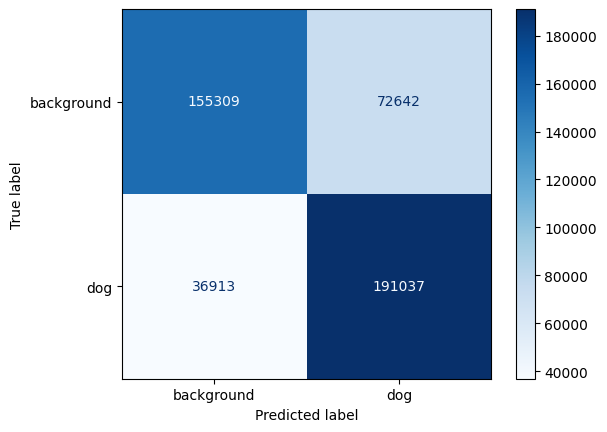

In [10]:
model = densityMask

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["background", "dog"])
disp.plot(cmap="Blues")
plt.show()


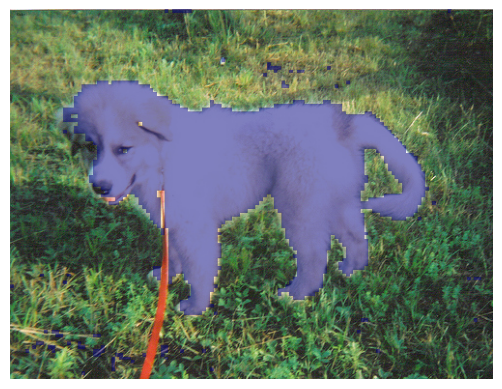

In [11]:
i = 5

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
downscaled_image, downscaled_mask = downscale(image, mask, size)

predictions = model.predict_image(downscaled_image)


plot_mask(image, upscale(predictions, image.size))

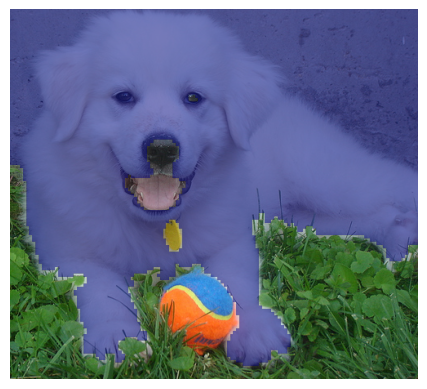

0.7152201138407298


In [12]:
i = 2
max_iter = 50

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
downscaled_image, downscaled_mask = downscale(image, mask, size)

predictions = model(downscaled_image, max_iter)
predictions = upscale(predictions, image.size) > threshold

plot_mask(image, predictions)
print(IoU(mask, predictions))

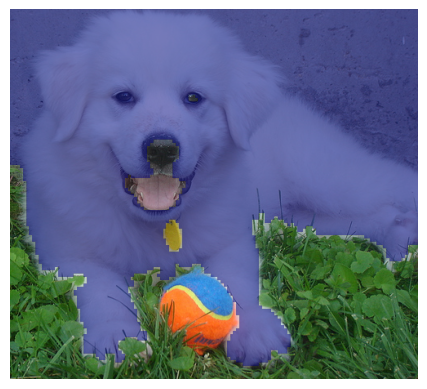

0.7152201138407298


In [13]:
i = 2
max_iter = 50

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
downscaled_image, downscaled_mask = downscale(image, mask, size)

predictions = model(downscaled_image, max_iter)
predictions = upscale(predictions, image.size) > threshold

plot_mask(image, predictions)
print(IoU(mask, predictions))

In [14]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

def parallel_segmentation(idx, model, max_iter, n_jobs=8):
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_single_image)(k, model, max_iter)
        for k in tqdm(idx)
    )
    return np.array(results)

def run_single_image(k, model, max_iter):
    image, (mask, cat) = test_dataset[k]
    mask = preprocess(mask)
    downscaled_image, downscaled_mask = downscale(image, mask, size)

    predictions = model(downscaled_image, max_iter)
    predictions = upscale(predictions, image.size) > threshold
    return IoU(mask, predictions)

def sequential_segmentation(idx, model, max_iter):
    results = []
    for k in tqdm(idx):
        iou = run_single_image(k, model, max_iter)
        results.append(iou)
    return np.array(results)

In [15]:
ious = parallel_segmentation(idx_test, model, max_iter)
print("Mean IoU:", ious.mean())

100%|██████████| 100/100 [02:11<00:00,  1.32s/it]


Mean IoU: 0.5835095249090294


In [ ]:
n_segments=100
compactness=20
def agg_func(x):
    mu = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    
    return np.concatenate((mu, std))

def agg_func(x):
    
    return np.mean(x, axis=0)

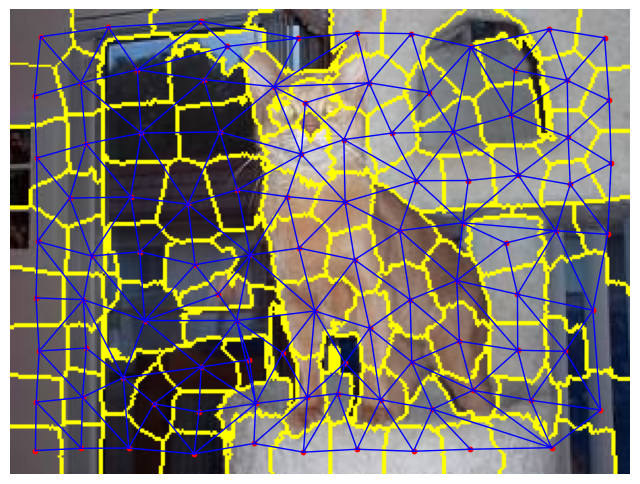

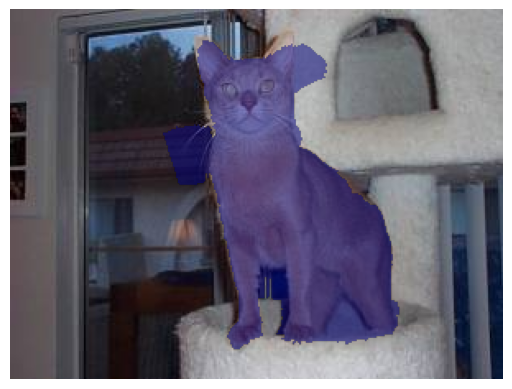

In [115]:
i = 1
image, (mask, cat) = test_dataset[idx_test[i]]
image = np.array(image)
mask = np.array(preprocess(mask))

segments, pixels, edges = utils.get_superpixels(image, n_segments=n_segments, compactness=compactness)

_, labels, super_mask = utils.process_super_pixel(image, mask, segments, pixels)
for i, p in enumerate(pixels):
    super_mask[segments == p] = labels[i]

utils.plot_superpixels(image, segments, edges)
plot_mask(image, super_mask)

In [116]:
features = []
labels = []

for i in tqdm(idx_train):
    image, (mask, cat) = dataset[i]
    mask = preprocess(mask)
    segments, pixels, edges = utils.get_superpixels(image, n_segments=n_segments, compactness=compactness)
    feature, label, _ = utils.process_super_pixel(image, mask, segments, pixels, agg_func=agg_func)
    features.append(feature)
    labels.append(label)

features = np.concatenate(features)
labels = np.concatenate(labels)

idx_0 = np.where(labels == 0)[0]
idx_1 = np.where(labels == 1)[0]

n = min(len(idx_0), len(idx_1))

idx_0_balanced = np.random.choice(idx_0, size=n, replace=False)
idx_1_balanced = np.random.choice(idx_1, size=n, replace=False)

balanced_idx = np.concatenate([idx_0_balanced, idx_1_balanced])
np.random.shuffle(balanced_idx)

features = features[balanced_idx]
labels = labels[balanced_idx]


  0%|          | 0/100 [00:00<?, ?it/s]

TypeError: 'NoneType' object is not callable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

logisticMask = models.SuperLogisticMask(agg_func=agg_func)
rdfMask = models.SuperSegment(RandomForestClassifier(10, max_depth=2), agg_func=agg_func)
densityMask = models.SuperDensityMask(agg_func=agg_func)

logisticMask.fit(X_train, y_train)
rdfMask.fit(X_train, y_train)
densityMask.fit(X_train, y_train)

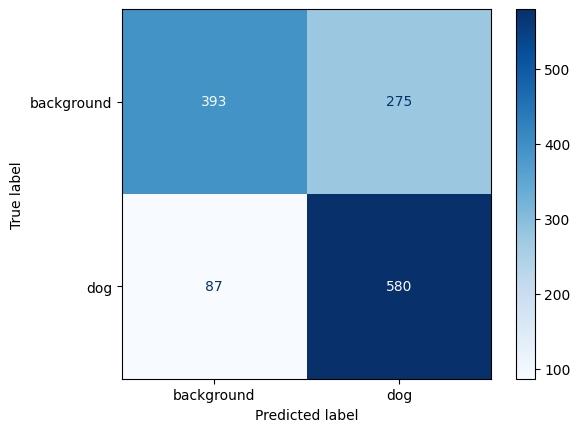

In [ ]:
model = densityMask

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["background", "dog"])
disp.plot(cmap="Blues")
plt.show()

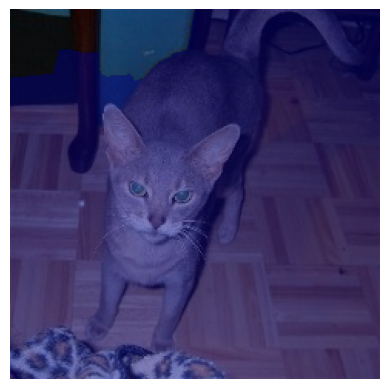

0.3487244754721219


In [ ]:
i = 8

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
image = np.array(image)

predictions = model(image, 50)
    
plot_mask(image, predictions)
print(IoU(mask, predictions))

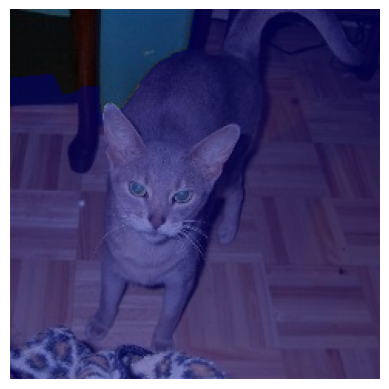

0.3532903275059165


In [ ]:
i = 8

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
image = np.array(image)

predictions = model(image, 50, trw=True)
    
plot_mask(image, predictions)
print(IoU(mask, predictions))

In [ ]:
def run_single_image(k, model, max_iter, trw):
    image, (mask, cat) = test_dataset[k]
    mask = preprocess(mask)
    image = np.array(image)

    predictions = model(image, max_iter, trw=trw)
    return IoU(mask, predictions)

def sequential_segmentation(idx, model, max_iter, trw):
    results = []
    for k in tqdm(idx):
        iou = run_single_image(k, model, max_iter, trw)
        results.append(iou)
    return np.array(results)

In [ ]:
trw = True

ious = sequential_segmentation(idx_test, model, max_iter, trw)
print("Mean IoU:", ious.mean())

  0%|          | 0/98 [00:00<?, ?it/s]

Mean IoU: 0.5007455308302077


In [ ]:
trw = False

ious = sequential_segmentation(idx_test, model, max_iter, trw)
print("Mean IoU:", ious.mean())

  0%|          | 0/98 [00:00<?, ?it/s]

Mean IoU: 0.4781020391107016
